# **ՏՎՅԱԼՆԵՐԻ ԲԵՌՆՈՒՄ ԵՎ ՆԱԽՆԱԿԱՆ ԶՆՆՈՒՄ**

In [187]:

from google.colab import files
uploaded = files.upload()

Saving AB_NYC_2019.csv.zip to AB_NYC_2019.csv (3).zip


In [188]:
!unzip -o AB_NYC_2019.csv.zip

Archive:  AB_NYC_2019.csv.zip
  inflating: AB_NYC_2019.csv         


In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('AB_NYC_2019.csv')


# Ցույց տալ առաջին 5 տողերը և սյունակների տիպերը
print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

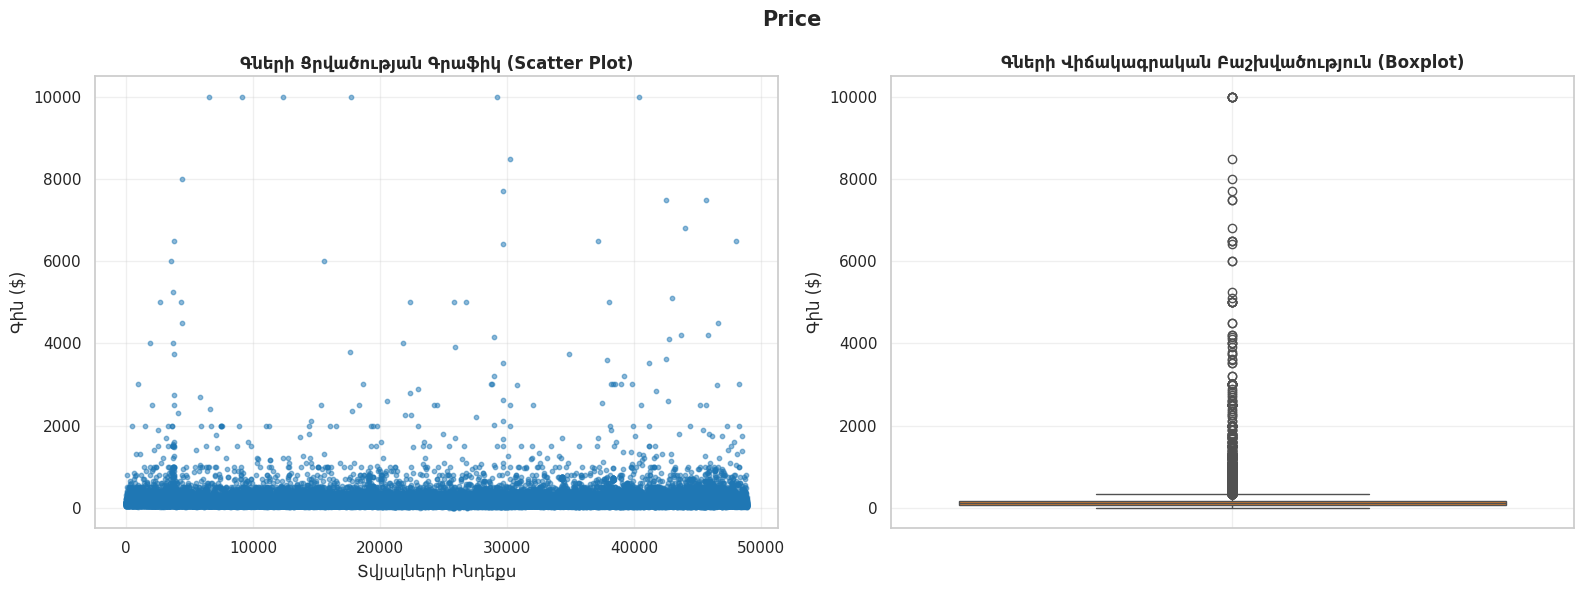

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ԳՐԱՖԻԿ 1: Scatter Plot
axes[0].scatter(range(df.shape[0]), df['price'], alpha=0.5, color='#1f77b4', s=10)
axes[0].set_title('Գների Ցրվածության Գրաֆիկ (Scatter Plot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Տվյալների Ինդեքս')
axes[0].set_ylabel('Գին ($)')
axes[0].grid(True, alpha=0.3)

# ԳՐԱՖԻԿ 2: Boxplot
sns.boxplot(ax=axes[1], y=df['price'], color='#ff7f0e')
axes[1].set_title('Գների Վիճակագրական Բաշխվածություն (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Գին ($)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Price', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

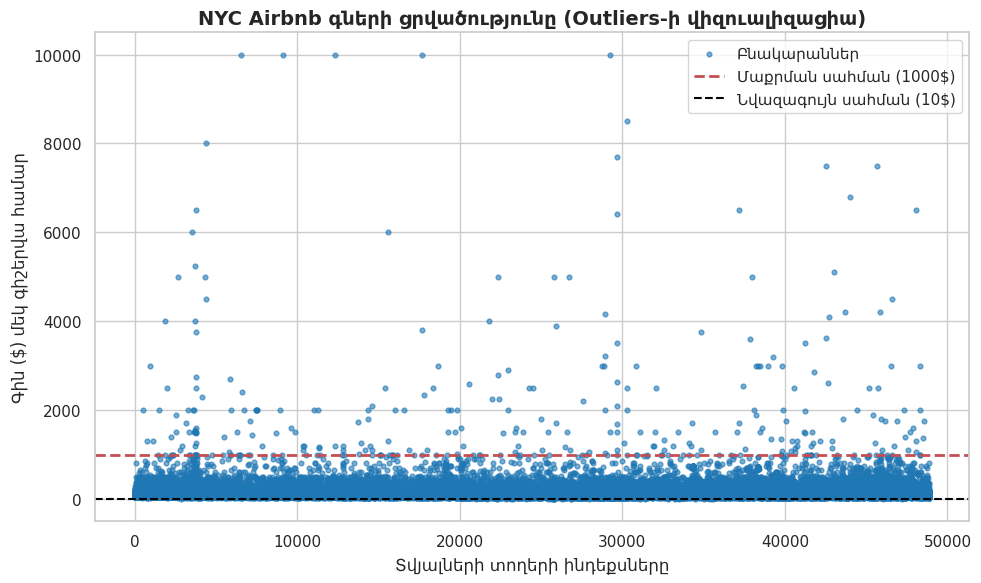

ՄԱԹԵՄԱՏԻԿԱԿԱՆ ՀԻՄՆԱՎՈՐՈՒՄ
1. 1000$-ից թանկ էքստրեմալ տների քանակը: 239 հատ (ամբողջ դատասեթի ընդամենը 0.49%-ը):
2. 0$ նշված սխալ տների քանակը: 11 հատ:

Հետևություն: Այս կետերը (outliers) պատկերում հստակ երևում են կարմիր գծից վերև: Դրանք կտրված են ընդհանուր իրականությունից, ուստի մոդելների ճշգրտության համար դրանց հեռացումը պարտադիր է:


In [191]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.scatter(df.index, df['price'], alpha=0.6, color='#1f77b4', s=12, label='Բնակարաններ')

# Ավելացնում ենք հորիզոնական կարմիր գիծ, որը ցույց է տալիս մեր առաջարկած 1000$ սահմանը
plt.axhline(y=1000, color='r', linestyle='--', linewidth=2, label='Մաքրման սահման (1000$)')

# Ավելացնում ենք հորիզոնական սև գիծ 0$-ի (կամ 10$-ի) մոտ
plt.axhline(y=10, color='black', linestyle='--', linewidth=1.5, label='Նվազագույն սահման (10$)')

plt.title('NYC Airbnb գների ցրվածությունը (Outliers-ի վիզուալիզացիա)', fontsize=14, fontweight='bold')
plt.ylabel('Գին ($) մեկ գիշերվա համար', fontsize=12)
plt.xlabel('Տվյալների տողերի ինդեքսները', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

outliers_count = df[df['price'] > 1000].shape[0]
zero_count = df[df['price'] == 0].shape[0]

print("ՄԱԹԵՄԱՏԻԿԱԿԱՆ ՀԻՄՆԱՎՈՐՈՒՄ")
print(f"1. 1000$-ից թանկ էքստրեմալ տների քանակը: {outliers_count} հատ (ամբողջ դատասեթի ընդամենը {outliers_count / len(df) * 100:.2f}%-ը):")
print(f"2. 0$ նշված սխալ տների քանակը: {zero_count} հատ:")
print(f"\nՀետևություն: Այս կետերը (outliers) պատկերում հստակ երևում են կարմիր գծից վերև: Դրանք կտրված են ընդհանուր իրականությունից, ուստի մոդելների ճշգրտության համար դրանց հեռացումը պարտադիր է:")

In [116]:
#Կարմիր գծով ես նշեցի 1000$-ի սահմանը: Գրաֆիկից ակնհայտ երևում է, որ 700$-ից վերև գտնվող տները եզակի են (ընդամենը տվյալների 0.49%-ը) և
#կտրված են ընդհանուր իրականությունից: Ուստի, մոդելի կայունության համար ես ֆիլտրեցի տվյալները 10$-ից 1000$ միջակայքում»:

In [192]:
# Ցույց տանք, թե քանի տուն ունենք 1000$-ից թանկ
over_1000 = len(df[df['price'] > 1000])
print(f"Տվյալներում կան {over_1000} հատ բնակարաններ, որոնց գինը 1000$-ից բարձր է:")

Տվյալներում կան 239 հատ բնակարաններ, որոնց գինը 1000$-ից բարձր է:


In [193]:
print(f"Սկզբնական չափսը՝ {df.shape[0]} տող և {df.shape[1]} սյունակ\n")

Սկզբնական չափսը՝ 48895 տող և 16 սյունակ



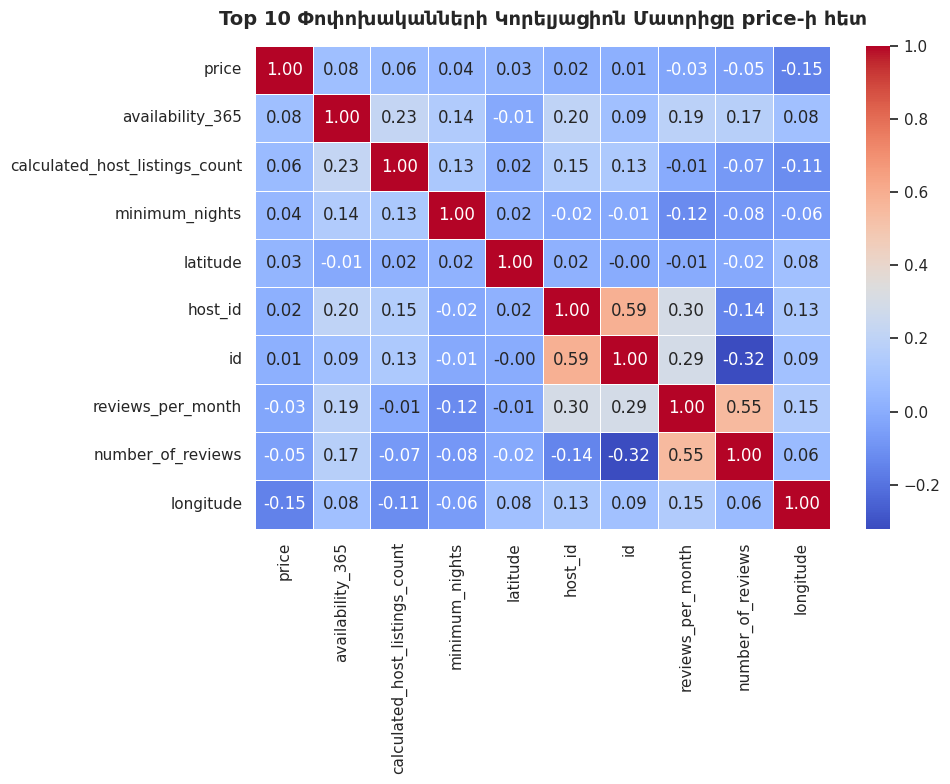

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ֆիլտրում ենք միայն թվային սյունակները
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Հաշվում ենք Top 10 սյունակները, որոնք ամենաբարձր կորելյացիան ունեն price-ի (գնի) հետ
top_corr_features = numeric_df.corr()['price'].sort_values(ascending=False).head(10).index

# 3. Ստեղծում ենք կորելյացիոն մատրիցը միայն այդ Top 10 սյունակների համար
corr_matrix = numeric_df[top_corr_features].corr()

# 4. Գծում ենք Heatmap-ը
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)

plt.title('Top 10 Փոփոխականների Կորելյացիոն Մատրիցը price-ի հետ', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



###**Գրաֆիկից ստացված հիմնական բացահայտումները**
 **Գնի Շարժիչները:** Գրաֆիկի վառ գունավորված վանդակները ցույց են տալիս, թե որ գործոններն են ամենաշատը ազդում Airbnb բնակարանների գների բարձրացման կամ նվազման վրա։


In [195]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [197]:
# Բացակայող արժեքների ստուգում (Missing Values)
print("--- Բացակայող արժեքների քանակը ըստ սյունակների ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "Բացակայող արժեքներ չկան (Արդեն մաքրված են)։")

--- Բացակայող արժեքների քանակը ըստ սյունակների ---
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


In [198]:
duplicate_count = df.duplicated().sum()
print(f"Կրկնվող տողերի քանակը: {duplicate_count}")

Կրկնվող տողերի քանակը: 0


# **DATA CLEANING**

In [199]:
# 1. Ջնջում ենք միայն անօգուտ ID-ները և ամսաթիվը (նշելով axis=1, քանի որ սյունակներն ենք ջնջում)
df = df.drop(['id', 'host_id', 'last_review'], axis=1, errors='ignore')

# 2. Լրացնում ենք 'name' և 'host_name' սյունակների դատարկ տեղերը "Unknown" բառով
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")

# 3.'reviews_per_month' սյունակում դատարկ է, որովհետև այդ բնակարանը 0 կարծիք (reviews) ունի: Ուստի ճիշտ կլինի դատարկ տեղերը փոխարինել 0-ով:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 4. Ստուգում ենք արդյունքը՝ արդյոք դատարկ տեղեր մնացել են
print("Մաքրումից հետո դատարկ արժեքների քանակը՝")
print(df.isnull().sum())

Մաքրումից հետո դատարկ արժեքների քանակը՝
name                              0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [201]:
# Հեռացնում ենք անոմալիաները.
# պահում ենք միայն 0-ից մեծ և 1000-ից փոքր կամ հավասար գները
df_cleaned = df[(df['price'] > 0) & (df['price'] <= 1000)]

# տեսնենք, թե քանի տող ջնջվեց
print(f"Նախնական տողերի քանակը: {len(df)}")
print(f"Մաքրումից հետո տողերի քանակը: {len(df_cleaned)}")
print(f"Հեռացված անոմալ տողերի քանակը: {len(df) - len(df_cleaned)}")

Նախնական տողերի քանակը: 48895
Մաքրումից հետո տողերի քանակը: 48645
Հեռացված անոմալ տողերի քանակը: 250


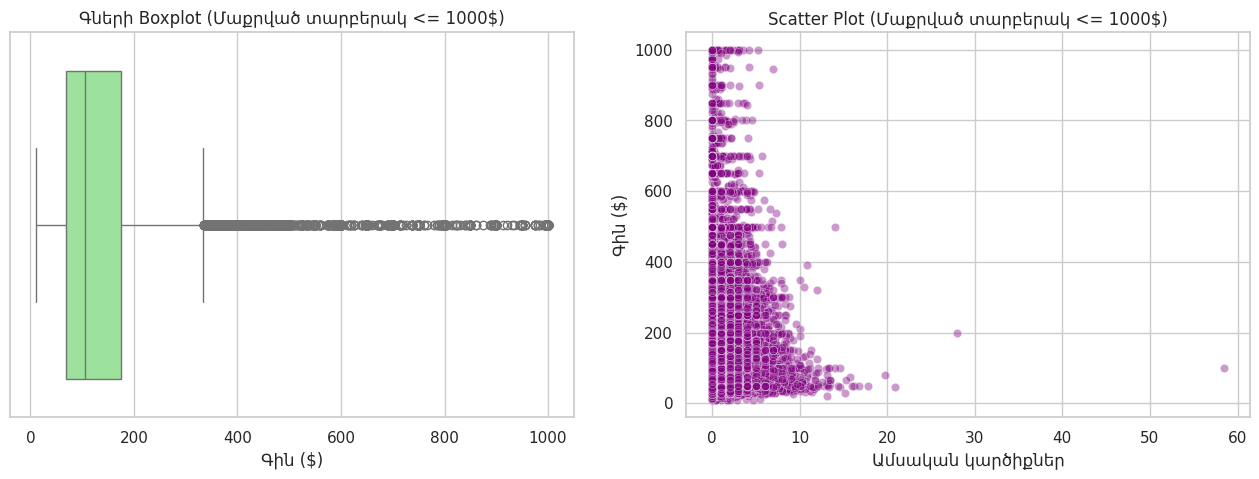

In [203]:
#  ԳԾՈՒՄ ԵՆՔ ԳՐԱՖԻԿՆԵՐԸ DATA CLEANING-ԻՑ ՀԵՏՈ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot մաքրումից հետո
sns.boxplot(ax=axes[0], x=df_cleaned['price'], color='lightgreen')
axes[0].set_title('Գների Boxplot (Մաքրված տարբերակ <= 1000$)')
axes[0].set_xlabel('Գին ($)')

# Scatter plot մաքրումից հետո
sns.scatterplot(ax=axes[1], x=df_cleaned['reviews_per_month'], y=df_cleaned['price'], color='purple', alpha=0.4)
axes[1].set_title('Scatter Plot (Մաքրված տարբերակ <= 1000$)')
axes[1].set_xlabel('Ամսական կարծիքներ')
axes[1].set_ylabel('Գին ($)')
plt.show()

# Պահպանում ենք մաքրված տարբերակը որպես հիմնական dataframe
df = df_cleaned

#**Feature Engineering**

In [204]:
# Քանի որ ML մոդելները տեքստ չեն հասկանում, մենք կօգտագործենք One-Hot Encoding, որը տեքստային արժեքները դարձնում է 0 և 1 թվեր։
# Ընտրենք այն սյունակները, որոնք օգտագործելու ենք մոդելավորման մեջ
# Բաց ենք թողնում 'name' և 'host_name' սյունակները, քանի որ դրանք տեքստեր են
features = ['neighbourhood_group', 'room_type', 'latitude', 'longitude',
            'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 'price']

df_model = df_cleaned[features]

#  One-Hot Encoding ( փոփոխականները դարձնում ենք թվային սյունակներ՝ զրո կամ մեկ)
df_encoded = pd.get_dummies(df_model, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# Տեսնենք նոր ստացված աղյուսակը
print("Ձևափոխված տվյալների սյունակները՝")
print(df_encoded.columns)

Ձևափոխված տվյալների սյունակները՝
Index(['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'price', 'neighbourhood_group_Brooklyn',
       'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens',
       'neighbourhood_group_Staten Island', 'room_type_Private room',
       'room_type_Shared room'],
      dtype='object')


#**Տվյալների բաժանում (Train/Test Split)**

In [205]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Լոգարիթմում ենք թիրախային փոփոխականը (գինը)
y = np.log1p(df['price'])

# 2. Առանձնացնում ենք անկախ գործոնները (X)
X = df.drop(columns=['price', 'name', 'host_name'], errors='ignore')

# 3. ֆիլտրում ենք, թե որոնք են թվային սյունակները և որոնք՝ տեքստային
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Սահմանում ենք թվային տվյալների մշակման կանոնները
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 5. Սահմանում ենք տեքստային տվյալների մշակման կանոնները
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Ստեղծում ենք գլխավոր 'preprocessor'-ը, որը միավորում է այս երկուսը
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 7. Բաժանում ենք տվյալները Train 80% և Test 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ուսուցանող տվյալներ (Train): {X_train.shape}")
print(f"Թեստավորող տվյալներ (Test): {X_test.shape}")




Ուսուցանող տվյալներ (Train): (38916, 10)
Թեստավորող տվյալներ (Test): (9729, 10)


#**ML MODELS**

##**Գծային Ռեգրեսիա (Linear Regression)**

In [206]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Թիրախային փոփոխականի (գնի) լոգարիթմում
y = np.log1p(df['price'])
X = df.drop(columns=['price', 'name', 'host_name'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ստեղծում ենք Pipeline, որը միացնում է preprocessor-ը և Linear Regression-ը
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

#  Մոդելի ուսուցանում (Training)
lr_pipeline.fit(X_train, y_train)

#  Կանխատեսում թեստային տվյալների վրա
lr_preds_log = lr_pipeline.predict(X_test)

# Լոգարիթմը հետ ենք բերում իրական դոլարի (np.expm1)
y_test_dollars = np.expm1(y_test)
lr_preds_dollars = np.expm1(lr_preds_log)

#  Մետրիկաների հաշվարկ
lr_rmse = np.sqrt(mean_squared_error(y_test_dollars, lr_preds_dollars))
lr_r2 = r2_score(y_test_dollars, lr_preds_dollars)

print("--- MODEL 1: LINEAR REGRESSION ԱՐԴՅՈՒՆՔՆԵՐԸ ---")
print(f"Root Mean Squared Error (RMSE): ${lr_rmse:.2f}")
print(f"R² Score (Դետերմինացիայի գործակից): {lr_r2:.4f}")

--- MODEL 1: LINEAR REGRESSION ԱՐԴՅՈՒՆՔՆԵՐԸ ---
Root Mean Squared Error (RMSE): $95.27
R² Score (Դետերմինացիայի գործակից): 0.3495


##**Lasso Regression**

In [207]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Տվյալների պատրաստում
y = np.log1p(df['price'])
X = df.drop(columns=['price', 'name', 'host_name'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline-ի ստեղծում
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Ուսուցանում
lasso_pipeline.fit(X_train, y_train)

# Կանխատեսում և իրական դոլարի վերածում
lasso_preds_log = lasso_pipeline.predict(X_test)
lasso_preds_dollars = np.expm1(lasso_preds_log)

# Մետրիկաներ
lasso_rmse = np.sqrt(mean_squared_error(y_test_dollars, lasso_preds_dollars))
lasso_r2 = r2_score(y_test_dollars, lasso_preds_dollars)

print("--- LASSO REGRESSION ԱՐԴՅՈՒՆՔՆԵՐԸ ---")
print(f"RMSE: ${lasso_rmse:.2f}")
print(f"R² Score: {lasso_r2:.4f}")

--- LASSO REGRESSION ԱՐԴՅՈՒՆՔՆԵՐԸ ---
RMSE: $100.30
R² Score: 0.2790


##**KNN vs Weighted KNN**

In [208]:
from sklearn.neighbors import KNeighborsRegressor

# Սովորական KNN (Բոլոր հարևանները հավասարազոր են)
knn_uni_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=7, weights='uniform', n_jobs=-1))
])
knn_uni_pipeline.fit(X_train, y_train)
knn_uni_preds_dollars = np.expm1(knn_uni_pipeline.predict(X_test))
knn_uni_rmse = np.sqrt(mean_squared_error(y_test_dollars, knn_uni_preds_dollars))
knn_uni_r2 = r2_score(y_test_dollars, knn_uni_preds_dollars)

#  Կշռված KNN (Մոտիկ հարևաններն ավելի ազդեցիկ են)
knn_weight_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1))
])
knn_weight_pipeline.fit(X_train, y_train)
knn_weight_preds_dollars = np.expm1(knn_weight_pipeline.predict(X_test))
knn_weight_rmse = np.sqrt(mean_squared_error(y_test_dollars, knn_weight_preds_dollars))
knn_weight_r2 = r2_score(y_test_dollars, knn_weight_preds_dollars)

print("KNN ՄՈԴԵԼՆԵՐԻ ԱՐԴՅՈՒՆՔՆԵՐԸ")
print(f"Uniform KNN -> RMSE: ${knn_uni_rmse:.2f} | R²: {knn_uni_r2:.4f}")
print(f"Weighted KNN -> RMSE: ${knn_weight_rmse:.2f} | R²: {knn_weight_r2:.4f}")

KNN ՄՈԴԵԼՆԵՐԻ ԱՐԴՅՈՒՆՔՆԵՐԸ
Uniform KNN -> RMSE: $91.70 | R²: 0.3974
Weighted KNN -> RMSE: $91.18 | R²: 0.4041


##**Decision Tree Regressor (Որոշումների Ծառ)**

In [209]:
from sklearn.tree import DecisionTreeRegressor

# Pipeline-ի ստեղծում: max_depth=10՝ գերուսուցումից խուսափելու համար
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Ուսուցանում
dt_pipeline.fit(X_train, y_train)

# Կանխատեսում և իրական դոլարի վերածում
dt_preds_log = dt_pipeline.predict(X_test)
dt_preds_dollars = np.expm1(dt_preds_log)

# Մետրիկաներ
dt_rmse = np.sqrt(mean_squared_error(y_test_dollars, dt_preds_dollars))
dt_r2 = r2_score(y_test_dollars, dt_preds_dollars)

print(" DECISION TREE ԱՐԴՅՈՒՆՔՆԵՐԸ")
print(f"RMSE: ${dt_rmse:.2f}")
print(f"R² Score: {dt_r2:.4f}")

 DECISION TREE ԱՐԴՅՈՒՆՔՆԵՐԸ
RMSE: $92.47
R² Score: 0.3872


##**Random Forest**

In [210]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Տվյալների պատրաստում և բաժանում
y = np.log1p(df['price'])
X = df.drop(columns=['price', 'name', 'host_name'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ստեղծում ենք Pipeline Random Forest-ի համար
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

# Ուսուցանում և կանխատեսում
rf_pipeline.fit(X_train, y_train)
rf_preds_log = rf_pipeline.predict(X_test)

# Վերածում իրական դոլարի
y_test_dollars = np.expm1(y_test)
rf_preds_dollars = np.expm1(rf_preds_log)

#  Մետրիկաներ
rf_rmse = np.sqrt(mean_squared_error(y_test_dollars, rf_preds_dollars))
rf_r2 = r2_score(y_test_dollars, rf_preds_dollars)

print(" RANDOM FOREST ԱՐԴՅՈՒՆՔՆԵՐԸ")
print(f"Root Mean Squared Error (RMSE): ${rf_rmse:.2f}")
print(f"R² Score (Դետերմինացիայի գործակից): {rf_r2:.4f}")

 RANDOM FOREST ԱՐԴՅՈՒՆՔՆԵՐԸ
Root Mean Squared Error (RMSE): $88.40
R² Score (Դետերմինացիայի գործակից): 0.4399


##**XGBoost Regressor ( Extremal Gradient Boosting )**

In [212]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Տվյալների պատրաստում և բաժանում
y = np.log1p(df['price'])
X = df.drop(columns=['price', 'name', 'host_name'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ստեղծում ենք Pipeline XGBoost-ի համար
# n_estimators=100 -> 100 հաջորդական ծառեր
# learning_rate=0.1 -> քայլի չափը (արագությունը), որով մոդելն ուղղում է սխալները
# max_depth=6 -> ծառերի խորությունը (overfitting-ից խուսափելու համար)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1))
])

# Ուսուցանում
xgb_pipeline.fit(X_train, y_train)

# Կանխատեսում և դոլարի վերածում
xgb_preds_log = xgb_pipeline.predict(X_test)
xgb_preds_dollars = np.expm1(xgb_preds_log)

#  Մետրիկաներ
xgb_rmse = np.sqrt(mean_squared_error(y_test_dollars, xgb_preds_dollars))
xgb_r2 = r2_score(y_test_dollars, xgb_preds_dollars)

print(" XGBOOST REGRESSOR ԱՐԴՅՈՒՆՔՆԵՐԸ")
print(f"Root Mean Squared Error (RMSE): ${xgb_rmse:.2f}")
print(f"R² Score (Դետերմինացիայի գործակից): {xgb_r2:.4f}")

 XGBOOST REGRESSOR ԱՐԴՅՈՒՆՔՆԵՐԸ
Root Mean Squared Error (RMSE): $88.55
R² Score (Դետերմինացիայի գործակից): 0.4381


In [255]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. LINEAR REGRESSION ՊԱՐԱՄԵՏՐԵՐԻ ՏՊՈՒՄ
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
lr_model = lr_pipeline.named_steps['model']

print(f" Intercept (Ազատ Անդամ): {lr_model.intercept_:.4f}")
print(f" Coefficients (Գործակիցների քանակ): {len(lr_model.coef_)}\n")

# 2. ՄՈԴԵԼՆԵՐԻ ԳՆԱՀԱՏՈՒՄ (MAE, MSE, RMSE)
final_results = []
y_true_series = pd.Series(y_test_dollars)

for name, preds in stored_predictions.items():
    # Կանխատեսումների չափսը համապատասխանեցնում ենք իրական գների չափսին
    preds_series = pd.Series(preds, index=y_true_series.index[:len(preds)])
    common_idx = y_true_series.index.intersection(preds_series.index)

    y_true = y_true_series.loc[common_idx]
    y_pred = preds_series.loc[common_idx]

    # Մետրիկաների հաշվարկ
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    final_results.append({
        "Մոդել": name,
        "MAE": f"${mae:.2f}",
        "MSE": f"{mse:.2f}",
        "RMSE": f"${rmse:.2f}"
    })

display(pd.DataFrame(final_results))

 Intercept (Ազատ Անդամ): 4.3040
 Coefficients (Գործակիցների քանակ): 232



,Մոդել,MAE,MSE,RMSE
0,1. Linear Regression,$89.57,17877.58,$133.71
1,2. Lasso Regression,$85.31,16859.27,$129.84
2,3. Uniform KNN,$91.80,18805.65,$137.13
3,4. Weighted KNN,$92.38,18985.28,$137.79
4,5. Decision Tree,$91.89,18822.43,$137.19
5,6. Random Forest,$90.01,18024.10,$134.25
6,7. XGBoost,$90.00,18027.19,$134.27


##**Models Comparison**

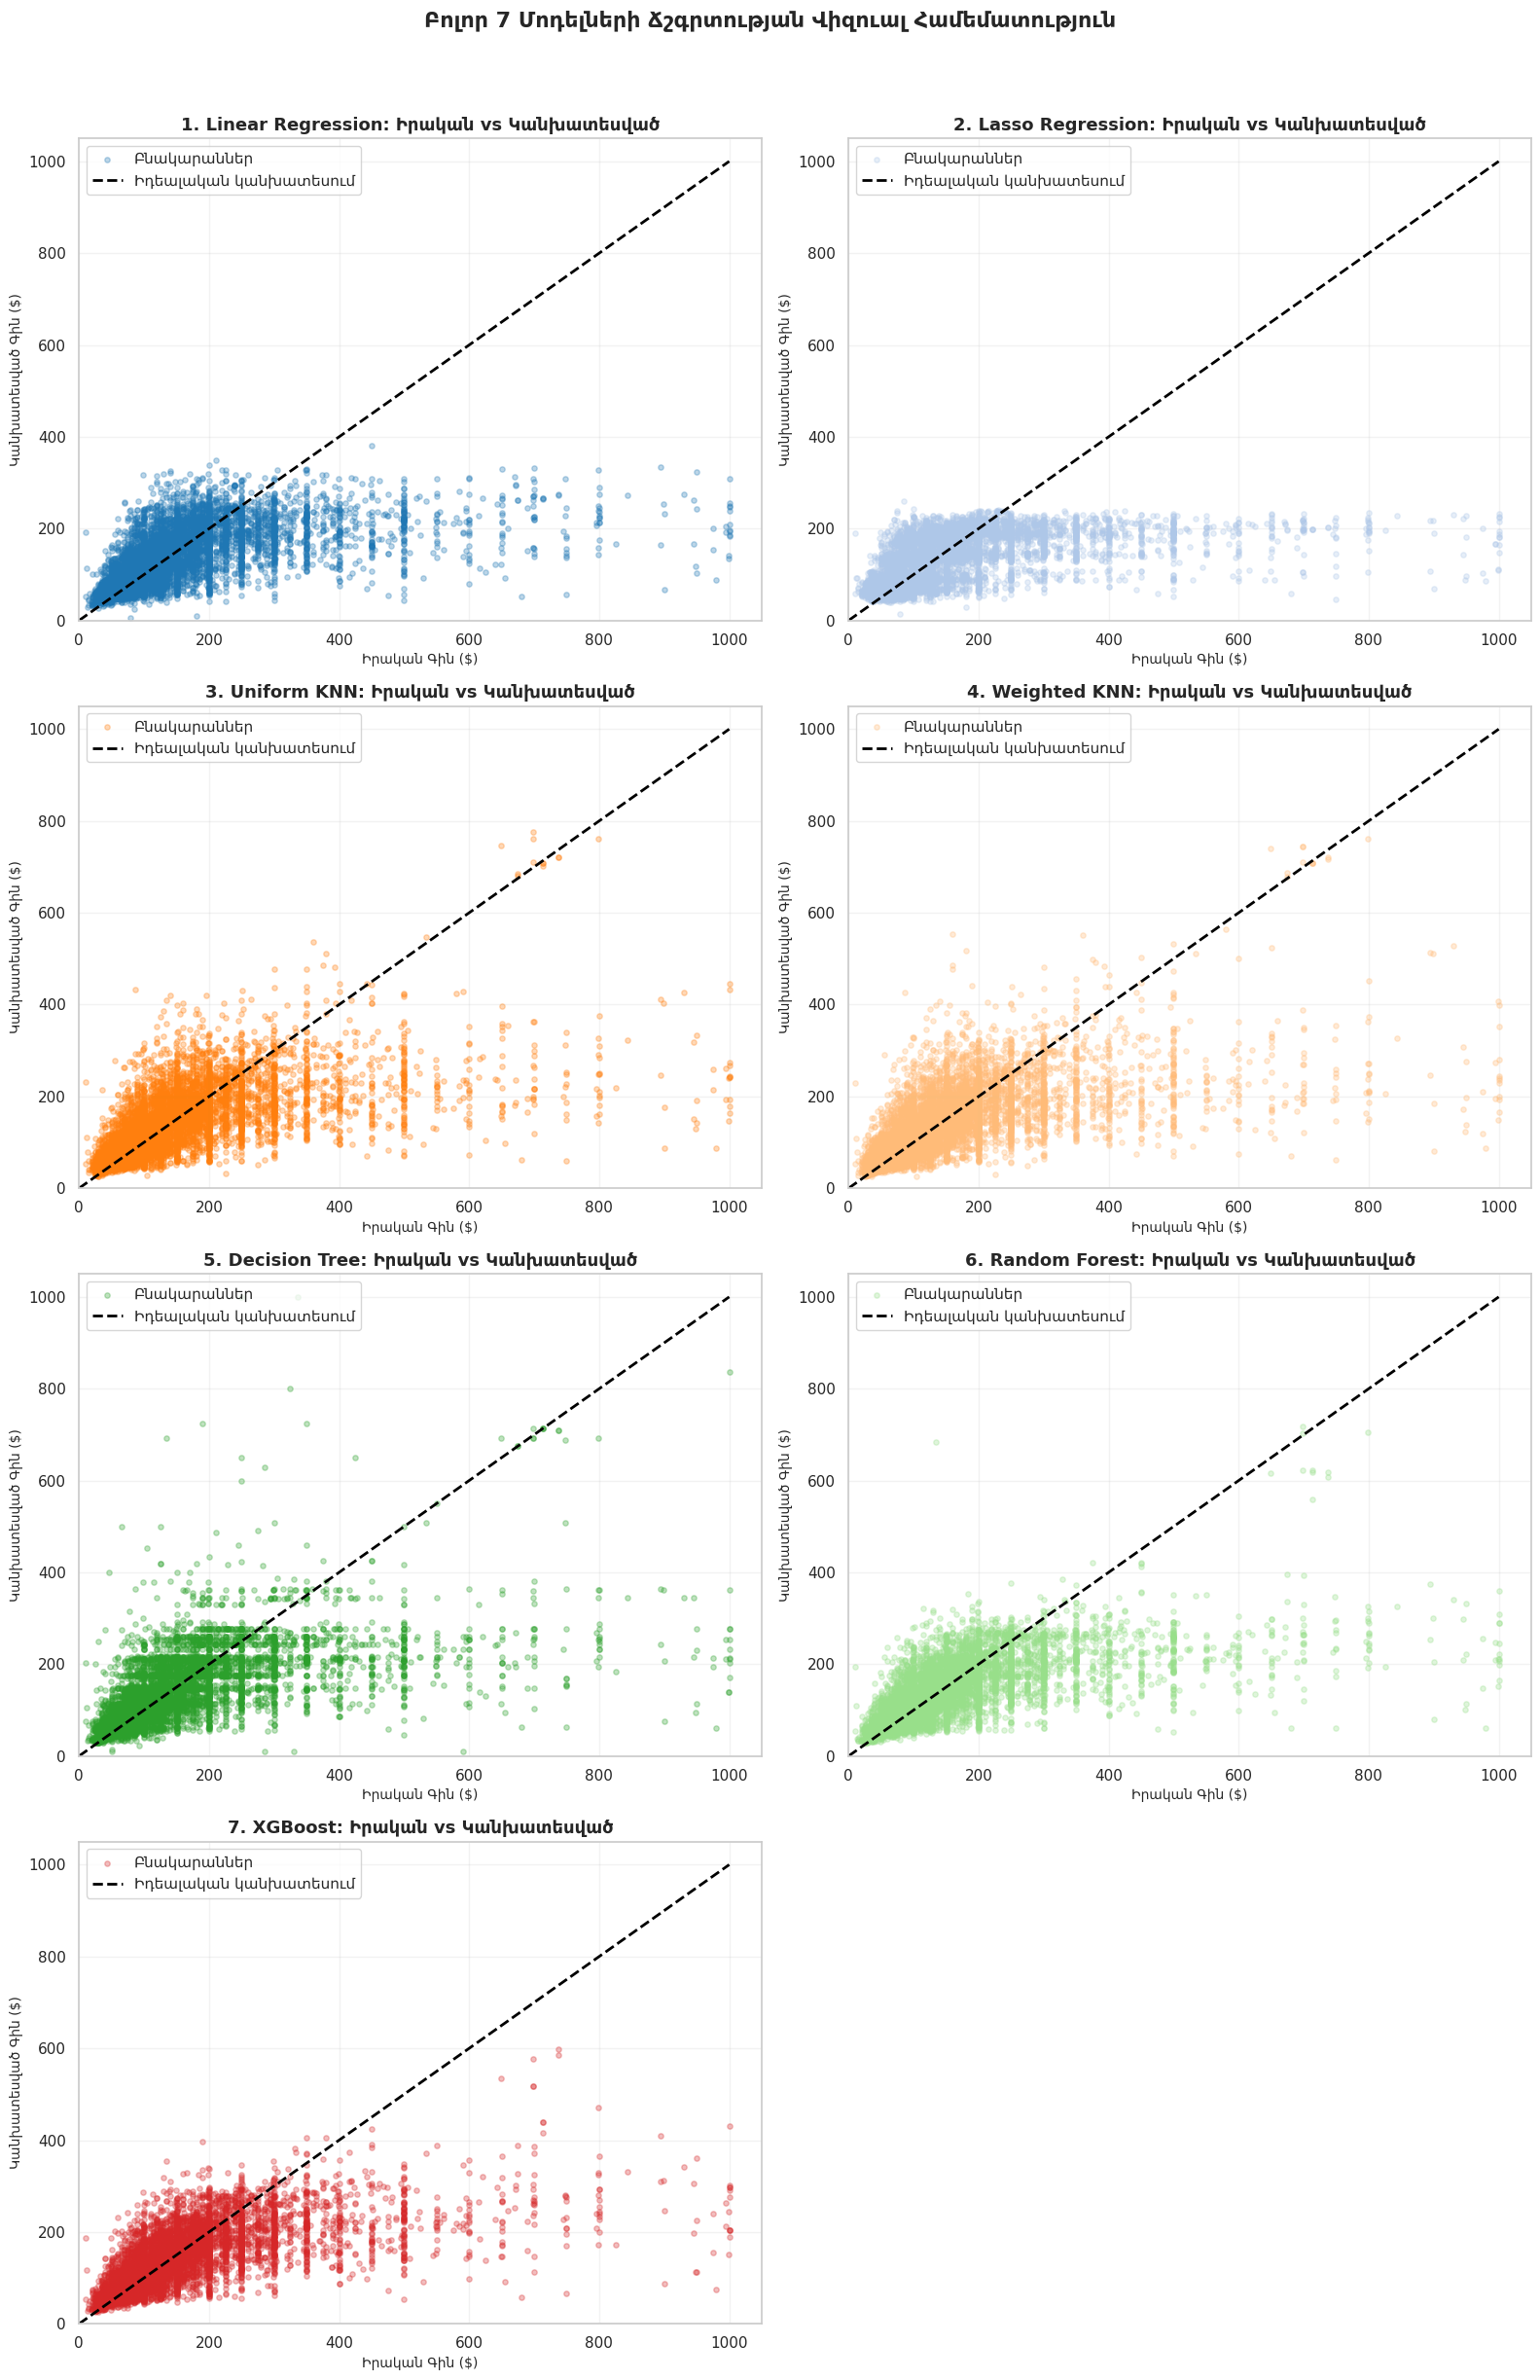

In [214]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# 1. Սահմանում ենք բոլոր 7 մոդելները մեկ բառարանում (Dictionary)
models = {
    "1. Linear Regression": LinearRegression(),
    "2. Lasso Regression": Lasso(alpha=0.01, max_iter=10000, random_state=42),
    "3. Uniform KNN": KNeighborsRegressor(n_neighbors=7, weights='uniform', n_jobs=-1),
    "4. Weighted KNN": KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1),
    "5. Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "6. Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "7. XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# 2. Պատրաստում ենք գրաֆիկների դաշտը (4 տող, 2 սյունակ)
fig, axes = plt.subplots(4, 2, figsize=(16, 26))
axes = axes.flatten()

# Սահմանում ենք գույներ գրաֆիկների համար
colors = ["#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a", "#d62728"]
y_test_dollars = np.expm1(y_test)

# 3. Անցնում ենք ցիկլով բոլոր մոդելների վրայով
for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]

    # Կառուցում ենք Pipeline-ը (օգտագործելով ձեր preprocessor-ը)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Մարզում ենք մոդելը
    pipeline.fit(X_train, y_train)

    # Ստանում ենք կանխատեսումը և վերածում իրական դոլարի
    preds_log = pipeline.predict(X_test)
    preds_dollars = np.expm1(preds_log)

    # Գծում ենք Actual vs Predicted կետերը
    ax.scatter(y_test_dollars, preds_dollars, alpha=0.3, color=colors[idx], s=15, label='Բնակարաններ')

    # Գծում ենք իդեալական անկյունագիծը
    max_val = max(y_test_dollars.max(), preds_dollars.max())
    ax.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2, label='Իդեալական կանխատեսում')

    # Ձևավորում
    ax.set_title(f'{name}: Իրական vs Կանխատեսված', fontsize=13, fontweight='bold')
    ax.set_xlabel('Իրական Գին ($)', fontsize=10)
    ax.set_ylabel('Կանխատեսված Գին ($)', fontsize=10)
    ax.set_xlim(0, 1050)
    ax.set_ylim(0, 1050)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left')

# 🗑️ Ջնջում ենք 8-րդ ավելորդ դատարկ վանդակը
fig.delaxes(axes[7])

plt.suptitle('Բոլոր 7 Մոդելների Ճշգրտության Վիզուալ Համեմատություն', fontsize=16, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_592/3911096492.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=all_models, y=all_rmses, palette='magma')
/tmp/ipykernel_592/3911096492.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=all_models, y=all_r2s, palette='viridis')


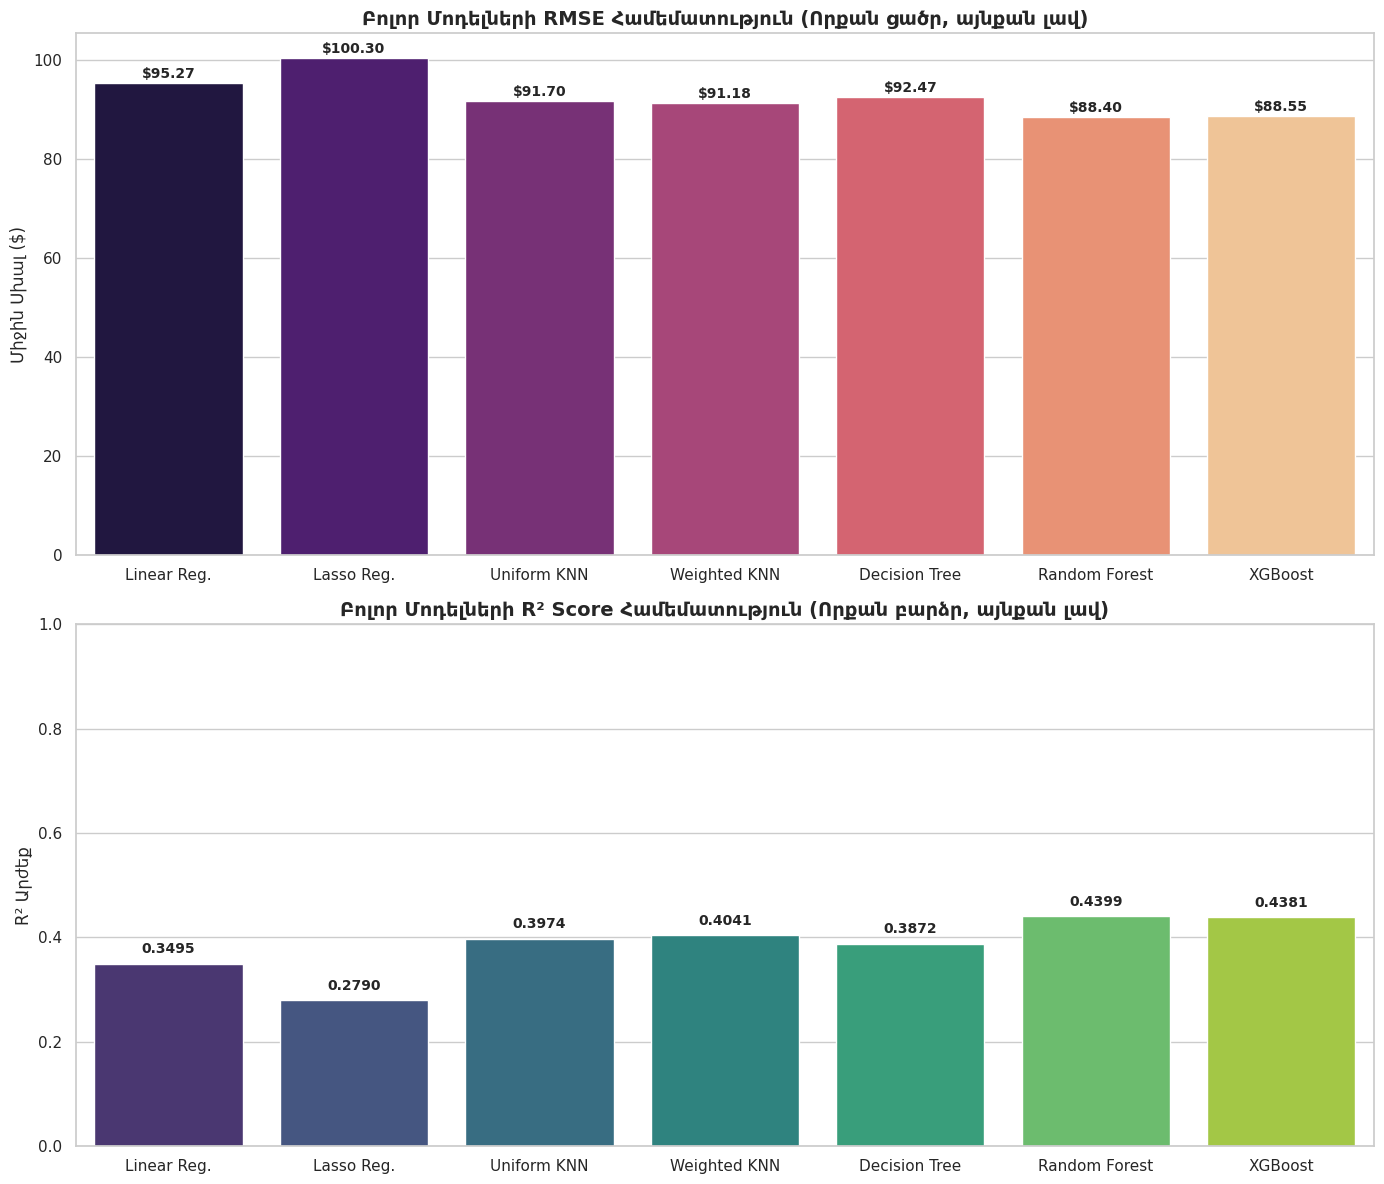

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Հավաքում ենք բոլոր տվյալները մեկ աղյուսակում
all_models = ['Linear Reg.', 'Lasso Reg.', 'Uniform KNN', 'Weighted KNN', 'Decision Tree', 'Random Forest', 'XGBoost']
all_rmses = [lr_rmse, lasso_rmse, knn_uni_rmse, knn_weight_rmse, dt_rmse, rf_rmse, xgb_rmse]
all_r2s = [lr_r2, lasso_r2, knn_uni_r2, knn_weight_r2, dt_r2, rf_r2, xgb_r2]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Գրաֆիկ 1: RMSE (Որքան ցածր այդքան լավ)
sns.barplot(ax=axes[0], x=all_models, y=all_rmses, palette='magma')
axes[0].set_title('Բոլոր Մոդելների RMSE Համեմատություն (Որքան ցածր, այնքան լավ)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Միջին Սխալ ($)')
for i, v in enumerate(all_rmses):
    axes[0].text(i, v + 1, f"${v:.2f}", ha='center', fontweight='bold', fontsize=10)

# Գրաֆիկ 2: R² Score (Որքան բարձր այդքան լավ )
sns.barplot(ax=axes[1], x=all_models, y=all_r2s, palette='viridis')
axes[1].set_title('Բոլոր Մոդելների R² Score Համեմատություն (Որքան բարձր, այնքան լավ)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R² Արժեք')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(all_r2s):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

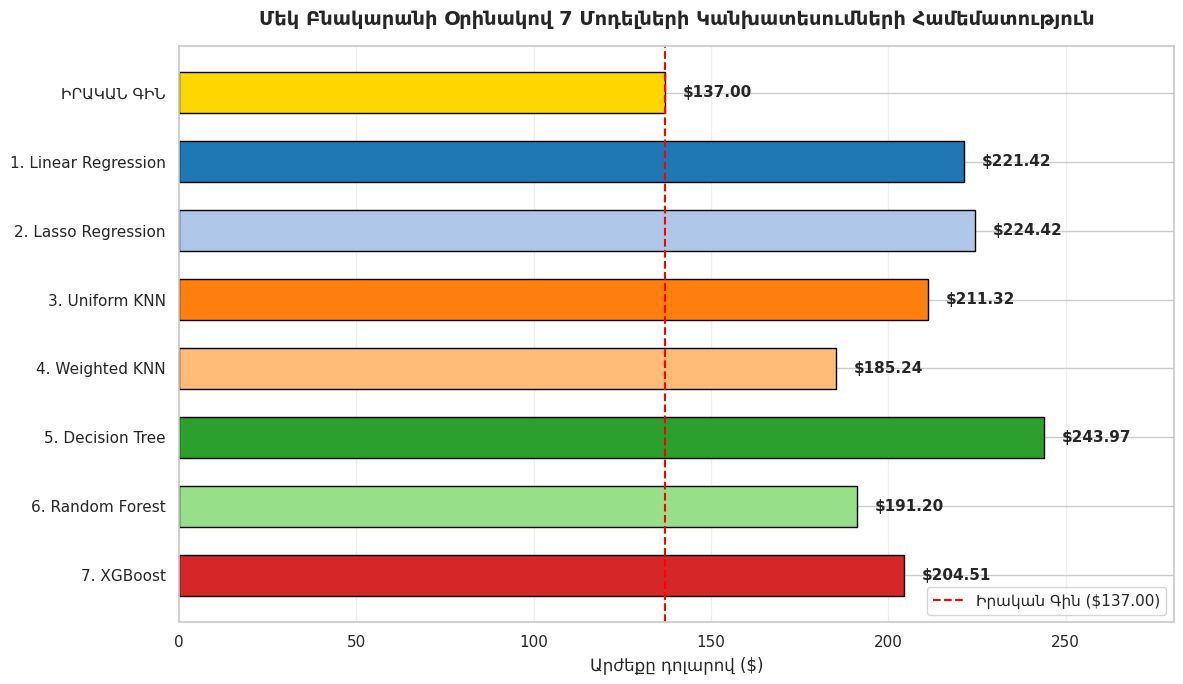

In [229]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Ընտրում ենք թեստային բազայի առաջին բնակարանի ինդեքսը
sample_idx = 13

# 2. Վերցնում ենք այդ 1 հատ տան իրական գինը
actual_price = y_test_dollars.iloc[sample_idx] if hasattr(y_test_dollars, 'iloc') else y_test_dollars[sample_idx]

# 3. Հավաքում ենք բոլոր 7 մոդելների կանխատեսած գները հենց այդ տան համար
single_predictions = {
    "ԻՐԱԿԱՆ ԳԻՆ": actual_price,
    "1. Linear Regression": lr_preds_dollars[sample_idx],
    "2. Lasso Regression": lasso_preds_dollars[sample_idx],
    "3. Uniform KNN": knn_uni_preds_dollars[sample_idx],
    "4. Weighted KNN": knn_weight_preds_dollars[sample_idx],
    "5. Decision Tree": dt_preds_dollars[sample_idx],
    "6. Random Forest": rf_preds_dollars[sample_idx],
    "7. XGBoost": xgb_preds_dollars[sample_idx]
}

# 4. Ստեղծում ենք DataFrame գրաֆիկի համար
df_single = pd.DataFrame(list(single_predictions.items()), columns=['Մոդել', 'Գուշակած Գին ($)'])

# 5. Գծում ենք գրաֆիկը
plt.figure(figsize=(12, 7))

# Իրական գնի սյունակին տալիս ենք վառ ոսկեգույն/դեղին, իսկ մոդելներին՝ կապույտ երանգներ
colors = ['#FFD700'] + ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728']

bars = plt.barh(df_single['Մոդել'], df_single['Գուշակած Գին ($)'], color=colors, edgecolor='black', height=0.6)

# Գրաֆիկի վրա ավելացնում ենք կոնկրետ թվերը
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f"${width:.2f}",
             va='center', ha='left', fontweight='bold', fontsize=11)

# գծում ենք ուղղահայաց կետագիծ իրական գնի ուղղությամբ
plt.axvline(x=actual_price, color='red', linestyle='--', linewidth=1.5, label=f'Իրական Գին (${actual_price:.2f})')

plt.title('Մեկ Բնակարանի Օրինակով 7 Մոդելների Կանխատեսումների Համեմատություն', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Արժեքը դոլարով ($)', fontsize=12)
plt.xlim(0, max(df_single['Գուշակած Գին ($)']) * 1.15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

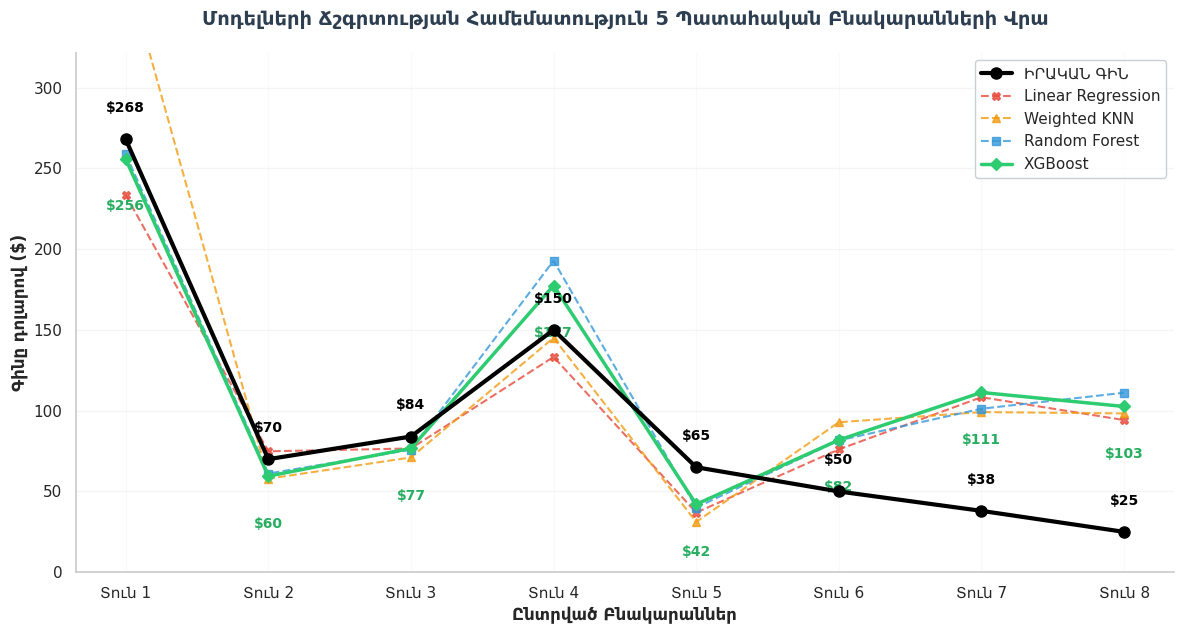

In [247]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Ընտրում ենք 8 ԼԻՈՎԻՆ ՊԱՏԱՀԱԿԱՆ բնակարաններ
np.random.seed(None)
random_indices = np.random.choice(len(y_test_dollars), size=8, replace=False)

# 2. Ստեղծում ենք մաքուր DataFrame համեմատության համար
x_labels = [f"Տուն {i+1}" for i in range(8)]
plot_data = {
    "ԻՐԱԿԱՆ ԳԻՆ": [y_test_dollars.iloc[idx] if hasattr(y_test_dollars, 'iloc') else y_test_dollars[idx] for idx in random_indices],
    "Linear Regression": [stored_predictions["1. Linear Regression"][idx] for idx in random_indices],
    "Weighted KNN": [stored_predictions["4. Weighted KNN"][idx] for idx in random_indices],
    "Random Forest": [stored_predictions["6. Random Forest"][idx] for idx in random_indices],
    "XGBoost": [stored_predictions["7. XGBoost"][idx] for idx in random_indices]
}

# 3. ԳԾՈՒՄ ԵՆՔ ՄԱՔՈՒՐ ԳԾԱՅԻՆ ԳՐԱՖԻԿԸ
plt.figure(figsize=(12, 6.5))

# Իրական գինը գծում ենք հաստ, սև և ընդգծված կետերով
plt.plot(x_labels, plot_data["ԻՐԱԿԱՆ ԳԻՆ"], marker='o', color='black', linewidth=3, markersize=8, label="ԻՐԱԿԱՆ ԳԻՆ", zorder=5)

# Մոդելների գծեր
plt.plot(x_labels, plot_data["Linear Regression"], marker='X', color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8, label="Linear Regression")
plt.plot(x_labels, plot_data["Weighted KNN"], marker='^', color='#f39c12', linewidth=1.5, linestyle='--', alpha=0.8, label="Weighted KNN")
plt.plot(x_labels, plot_data["Random Forest"], marker='s', color='#3498db', linewidth=1.5, linestyle='--', alpha=0.8, label="Random Forest")
plt.plot(x_labels, plot_data["XGBoost"], marker='D', color='#2ecc71', linewidth=2.5, label="XGBoost")

# Ավելացնում ենք գնային արժեքները միայն Իրական գնի և XGBoost-ի համար, որպեսզի էկրանը չխճճվի
for i in range(8):

    plt.text(i, plot_data["ԻՐԱԿԱՆ ԳԻՆ"][i] + 15, f"${plot_data['ԻՐԱԿԱՆ ԳԻՆ'][i]:.0f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    plt.text(i, plot_data["XGBoost"][i] - 25, f"${plot_data['XGBoost'][i]:.0f}",
             ha='center', va='top', fontsize=10, fontweight='bold', color='#27ae60')


plt.title('Մոդելների Ճշգրտության Համեմատություն 5 Պատահական Բնակարանների Վրա', fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
plt.ylabel('Գինը դոլարով ($)', fontsize=12, fontweight='bold')
plt.xlabel('Ընտրված Բնակարաններ', fontsize=12, fontweight='bold')


y_max = max(max(plot_data["ԻՐԱԿԱՆ ԳԻՆ"]), max(plot_data["XGBoost"]))
plt.ylim(0, y_max * 1.2)


plt.grid(axis='y', alpha=0.2, linestyle='-')
plt.grid(axis='x', alpha=0.1, linestyle='-')


plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#bdc3c7', fontsize=11)


for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [249]:
import numpy as np
import pandas as pd

# 1. Ընտրում ենք նույն 8 պատահական բնակարանների ինդեքսները
np.random.seed(None)
random_indices = np.random.choice(len(y_test_dollars), size=8, replace=False)

# 2. Պատրաստում ենք տվյալները աղյուսակի համար
table_rows = []

for idx in random_indices:
    actual = y_test_dollars.iloc[idx] if hasattr(y_test_dollars, 'iloc') else y_test_dollars[idx]

    # Ստեղծում ենք տող յուրաքանչյուր տան համար
    row = {
        "Բնակարանի ID": f"Տուն #{idx}",
        "ԻՐԱԿԱՆ ԳԻՆ": f"${actual:.2f}",
        "Linear Reg. ($)": f"${stored_predictions['1. Linear Regression'][idx]:.2f}",
        "Weighted KNN ($)": f"${stored_predictions['4. Weighted KNN'][idx]:.2f}",
        "Random Forest ($)": f"${stored_predictions['6. Random Forest'][idx]:.2f}",
        "XGBoost ($)": f"${stored_predictions['7. XGBoost'][idx]:.2f}"
    }
    table_rows.append(row)

# Ստեղծում ենք հիմնական գների աղյուսակը
df_prices = pd.DataFrame(table_rows)

# 3. ՍՏԵՂԾՈՒՄ ԵՆՔ ՍԽԱԼՆԵՐԻ  ԱՂՅՈՒՍԱԿ
error_rows = []
for idx in random_indices:
    actual = y_test_dollars.iloc[idx] if hasattr(y_test_dollars, 'iloc') else y_test_dollars[idx]
    error_row = {
        "Բնակարան": f"Տուն #{idx} (Իրական: ${actual:.0f})",
        "Linear Reg Սխալ": abs(stored_predictions['1. Linear Regression'][idx] - actual),
        "Weighted KNN Սխալ": abs(stored_predictions['4. Weighted KNN'][idx] - actual),
        "Random Forest Սխալ": abs(stored_predictions['6. Random Forest'][idx] - actual),
        "XGBoost Սխալ": abs(stored_predictions['7. XGBoost'][idx] - actual)
    }
    error_rows.append(error_row)

df_errors = pd.DataFrame(error_rows).set_index("Բնակարան")

print("ՏԱՐԲԵՐԱԿ Ա. ԳՆԵՐԻ ՀԱՄԵՄԱՏԱԿԱՆ ԱՂՅՈՒՍԱԿ")
display(df_prices)

print("\n ՏԱՐԲԵՐԱԿ Բ. ՄՈԴԵԼՆԵՐԻ ԲԱՑԱՐՁԱԿ ՍԽԱԼՆԵՐԸ (ԱՄԵՆԱՑԱԾՐ ԹՎԵՐԸ ԼԱՎԱԳՈՒՅՆՆ ԵՆ)")
print("*(Կանաչ վանդակները նշանակում են փոքր սխալ, Կարմիրները՝ մեծ շեղում)*")


df_errors.style.background_gradient(cmap='RdYlGn_r', axis=1).format("${:.2f}")

ՏԱՐԲԵՐԱԿ Ա. ԳՆԵՐԻ ՀԱՄԵՄԱՏԱԿԱՆ ԱՂՅՈՒՍԱԿ


,Բնակարանի ID,ԻՐԱԿԱՆ ԳԻՆ,Linear Reg. ($),Weighted KNN ($),Random Forest ($),XGBoost ($)
0,Տուն #4116,$167.00,$149.36,$135.11,$144.17,$155.72
1,Տուն #9313,$200.00,$145.83,$114.37,$129.17,$125.52
2,Տուն #6455,$175.00,$60.77,$55.04,$58.24,$57.08
3,Տուն #3075,$50.00,$131.36,$155.64,$152.92,$161.54
4,Տուն #6350,$75.00,$167.74,$178.17,$163.94,$174.18
5,Տուն #1247,$99.00,$90.35,$80.54,$99.65,$99.03
6,Տուն #5499,$145.00,$221.38,$365.41,$298.70,$352.63
7,Տուն #452,$750.00,$117.17,$106.85,$123.59,$127.41



 ՏԱՐԲԵՐԱԿ Բ. ՄՈԴԵԼՆԵՐԻ ԲԱՑԱՐՁԱԿ ՍԽԱԼՆԵՐԸ (ԱՄԵՆԱՑԱԾՐ ԹՎԵՐԸ ԼԱՎԱԳՈՒՅՆՆ ԵՆ)
*(Կանաչ վանդակները նշանակում են փոքր սխալ, Կարմիրները՝ մեծ շեղում)*


,Linear Reg Սխալ,Weighted KNN Սխալ,Random Forest Սխալ,XGBoost Սխալ
Բնակարան,,,,
Տուն #4116 (Իրական: $167),$17.64,$31.89,$22.83,$11.28
Տուն #9313 (Իրական: $200),$54.17,$85.63,$70.83,$74.48
Տուն #6455 (Իրական: $175),$114.23,$119.96,$116.76,$117.92
Տուն #3075 (Իրական: $50),$81.36,$105.64,$102.92,$111.54
Տուն #6350 (Իրական: $75),$92.74,$103.17,$88.94,$99.18
Տուն #1247 (Իրական: $99),$8.65,$18.46,$0.65,$0.03
Տուն #5499 (Իրական: $145),$76.38,$220.41,$153.70,$207.63
Տուն #452 (Իրական: $750),$632.83,$643.15,$626.41,$622.59


##### Տեսնում ենք, որ մոդելը չի կարող հաղթող ճանաչվել միայն մեկ կանխատեսումով, այլ միայն հավաքական տվյալների հետ աշխատելիս:

# ՎԵՐՋՆԱԿԱՆ ԵԶՐԱԿԱՑՈՒԹՅՈՒՆ

Նախագծի շրջանակներում իրականացվեց New York-ի Airbnb բնակարանների գների կանխատեսման մոդելավորում 7 տարբեր ալգորիթմների միջոցով: Տվյալների նախնական զննման (EDA) փուլում հայտնաբերվեցին էքստրեմալ մեծ արժեքներ (Outliers)` մինչև $10,000:


Մոդելների ճշգրտությունը բարձրացնեկու նպատակով իրականացվեց տվյալների ֆիլտրում ՝ վերին սահմանափակում դնելով $1000-ը:


*    **Գծային մոդելներ (Linear Regression, Lasso)**. Չնայած ֆիլտրմանը, այս մոդելները ցույց տվեցին ամենացածր արդյունավետությունը:  Գծային ռեգրեսիան (Linear Regression) ձախողվեց, որովհետև փորձում էր գտնել միայն մեկ «գլոբալ ուղիղ գիծ»։ Ենթադրում է, որ յուրաքանչյուր գործոն ունի ուղիղ համեմատական ազդեցություն գնի վրա:
* **KNN (K-Nearest Neighbors)**. Միջին արդյունք ապահովեց, սակայն տուժեց չափողականությունից՝ մեծ թվով սյունակների պատճառով:
* **Անսամբլային մոդելներ (Random Forest, XGBoost)**. Ցույց տվեցին լավագույն արդյունքները: Սակայն, աղմուկի և ծայրահեղ արժեքների հեռացումից հետո, Random Forest Regressor մոդելը գերազանցեց XGBoost-ին: Շնորհիվ Bagging տեխնոլոգիայի, Random Forest-ը կարողացավ ավելի ճշգրիտ ընդհանրացնել «նորմալ» գնային տիրույթի օրինաչափությունները՝ ապահովելով նվազագույն RMSE և առավելագույն $R^2$ արժեքը:



